### Let us perform some basic data understanding/data profiling with the codes we've learned earlier:
- Descriptive Statistics
- Understanding Data Types
- Find missing values

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/DSES")

Mounted at /content/drive


load the dataset as a pandas dataframe

In [ ]:
import pandas as pd #remember to use alias
cars_data=pd.read_csv('Cars93.csv') #no need specify full path if both .ipynb & csv in same folder
print(cars_data.shape) #check how many rows/columns

(93, 27)


preview the data

In [ ]:
cars_data.head() # 1st 5 rows

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
0,Acura,Integra,Small,12.9,15.9,18.8,25,31,NaN,Front,...,5,177,102,68,37,26.5,11.0,2705,non-USA,Acura Integra
1,Acura,Legend,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,Front,...,5,195,115,71,38,30.0,15.0,3560,non-USA,Acura Legend
2,Audi,90,Compact,25.9,29.1,32.3,20,26,Driver only,Front,...,5,180,102,67,37,28.0,14.0,3375,non-USA,Audi 90
3,Audi,100,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,Front,...,6,193,106,70,37,31.0,17.0,3405,non-USA,Audi 100
4,BMW,535i,Midsize,23.7,30.0,36.2,22,30,Driver only,Rear,...,4,186,109,69,39,27.0,13.0,3640,non-USA,BMW 535i


Perform descriptive statistics on both numerical and categorical data

In [ ]:
cars_data.describe(include='all')

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
count,93,93,93,93.000000,93.000000,93.000000,93.000000,93.000000,59,93,...,93.000000,93.000000,93.000000,93.000000,93.000000,91.000000,82.000000,93.000000,93,93
unique,32,93,6,NaN,NaN,NaN,NaN,NaN,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,93
top,Chevrolet,Integra,Midsize,NaN,NaN,NaN,NaN,NaN,Driver only,Front,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USA,Acura Integra
freq,8,1,22,NaN,NaN,NaN,NaN,NaN,43,67,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,1
mean,NaN,NaN,NaN,17.125806,19.509677,21.898925,22.365591,29.086022,NaN,NaN,...,5.086022,183.204301,103.946237,69.376344,38.956989,27.829670,13.890244,3072.903226,NaN,NaN
std,NaN,NaN,NaN,8.746029,9.659430,11.030457,5.619812,5.331726,NaN,NaN,...,1.038979,14.602382,6.819674,3.778986,3.223265,2.989072,2.997967,589.896510,NaN,NaN
min,NaN,NaN,NaN,6.700000,7.400000,7.900000,15.000000,20.000000,NaN,NaN,...,2.000000,141.000000,90.000000,60.000000,32.000000,19.000000,6.000000,1695.000000,NaN,NaN
25%,NaN,NaN,NaN,10.800000,12.200000,14.700000,18.000000,26.000000,NaN,NaN,...,4.000000,174.000000,98.000000,67.000000,37.000000,26.000000,12.000000,2620.000000,NaN,NaN
50%,NaN,NaN,NaN,14.700000,17.700000,19.600000,21.000000,28.000000,NaN,NaN,...,5.000000,183.000000,103.000000,69.000000,39.000000,27.500000,14.000000,3040.000000,NaN,NaN
75%,NaN,NaN,NaN,20.300000,23.300000,25.300000,25.000000,31.000000,NaN,NaN,...,6.000000,192.000000,110.000000,72.000000,41.000000,30.000000,15.000000,3525.000000,NaN,NaN


lets take a look at cat columns only

In [ ]:
cars_data.describe(include=object)

,Manufacturer,Model,Type,AirBags,DriveTrain,Cylinders,Man.trans.avail,Origin,Make
count,93,93,93,59,93,93,93,93,93
unique,32,93,6,2,3,6,2,2,93
top,Chevrolet,Integra,Midsize,Driver only,Front,4,Yes,USA,Acura Integra
freq,8,1,22,43,67,49,61,48,1


### From this point onwards, we will begin the EDA by drawing appropriate graphs:
- Univariate-> Histogram, boxplot, bar graph
- Bivariate-> Scatter plot, Bar graph
> We will use the seaborn library riding on top the matplotlib library.

### Plot 1: Histogram on one particular variable 'MPG.city'

If you encounter error due to no module matplotlib found, please do a *conda install matplotlib* in Anaconda Prompt. Similarly for seaborn.

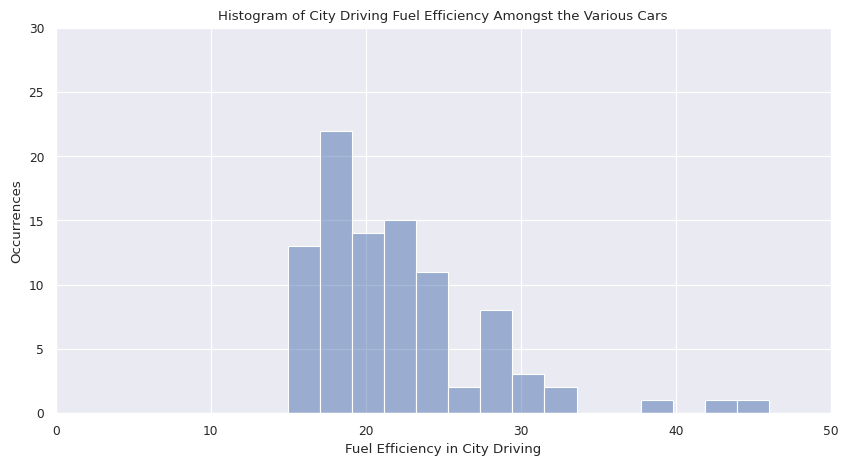

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#set figure size
plt.figure(figsize=(10,5))
#set theme
sns.set_theme(context='paper',style='darkgrid') #paper->notebook->talk->poster, to define default font size/type, etc
#turn off legend because don't need it for univariate
g=sns.histplot(data=cars_data[['MPG.city']], bins=15, color='blue', legend=False)
#provide context by giving proper labels
g.set(xlabel='Fuel Efficiency in City Driving', ylabel='Occurrences', \
      title='Histogram of City Driving Fuel Efficiency Amongst the Various Cars')
plt.xlim(0, 50) #otherwise limits are automatically defined based on range
plt.ylim(0, 30)
plt.show() #not necessary for .ipynb but require for .py codes

Here’s what you can read from the histogram:

| Observation                         | What it means for you                                                                                                                                      |
| ----------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Main cluster around 18 – 25 mpg** | Most of the cars in the dataset deliver roughly 18 to 25 miles per gallon when driven in the city. This is the “typical” fuel-efficiency range.            |
| **Right-hand tail above 30 mpg**    | Only a handful of cars achieve better than 30 mpg, and even fewer exceed 40 mpg. These are high-efficiency outliers (often hybrids or very small engines). |
| **Few or no cars below \~15 mpg**   | Truly inefficient city-driving cars are either absent or very rare in this sample.                                                                         |
| **Overall shape is right-skewed**   | Because of the small number of very efficient cars, the distribution has a long tail to the right. The median is therefore a bit lower than the mean.      |

**Key takeaway**
When choosing from this set of cars, you’re most likely to end up with something in the 18-25 mpg range for city driving. Vehicles that significantly beat 30 mpg are outliers rather than the norm.


### Plot 2: Box plot

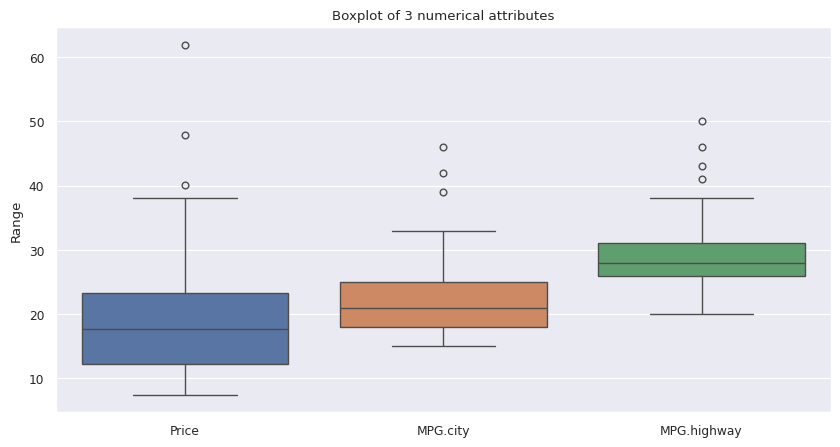

In [ ]:
#Although boxplot is an univariate analysis->box and whiskers tell you abt a particular column
#More efficient by plotting many numerical columns in the same figure
#We need to create a subset that consists of only 3 numerical columns
plt.figure(figsize=(10,5))
cars_sub=cars_data[['Price','MPG.city','MPG.highway']]
#Plot a boxplot
g=sns.boxplot(data = cars_sub)
#give context to the plot
g.set(ylabel='Range', title='Boxplot of 3 numerical attributes')
plt.show()

Takeaway: Cars typically are less fuel-efficient for city driving. For the various fields, there are only upper outliers, this means 'premium' cases exists but are few.

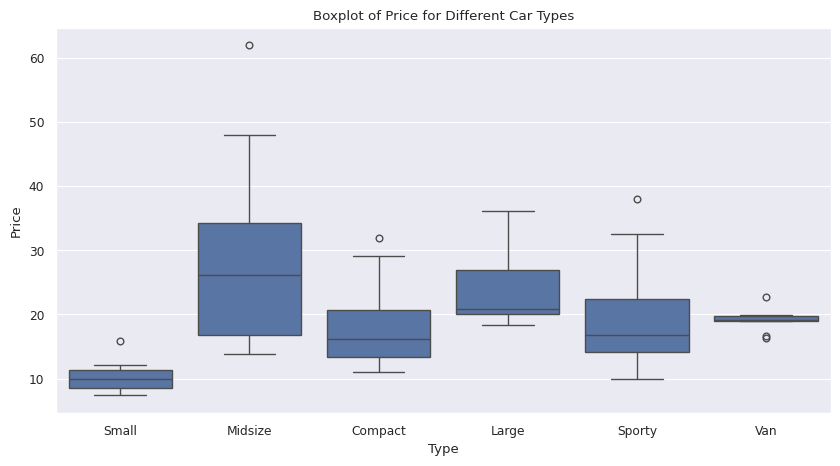

In [ ]:
#Plot a boxplot of price distribution amongst different car types
plt.figure(figsize=(10,5))
g=sns.boxplot(x='Type', y='Price', data = cars_data)
#give context to the plot
g.set(title='Boxplot of Price for Different Car Types')
plt.show()

Take-away:
- There seemed to be a relationship between car type and price but interesting to note that some mid size cars were priced higher than large cars.
- Large cars (and also sporty ones)seemed to have right-skewed distribution (some models were priced much higher than the rest in the same category).
- Vans seemed to be priced in a very limited range.

### Plot 3: Bar graph

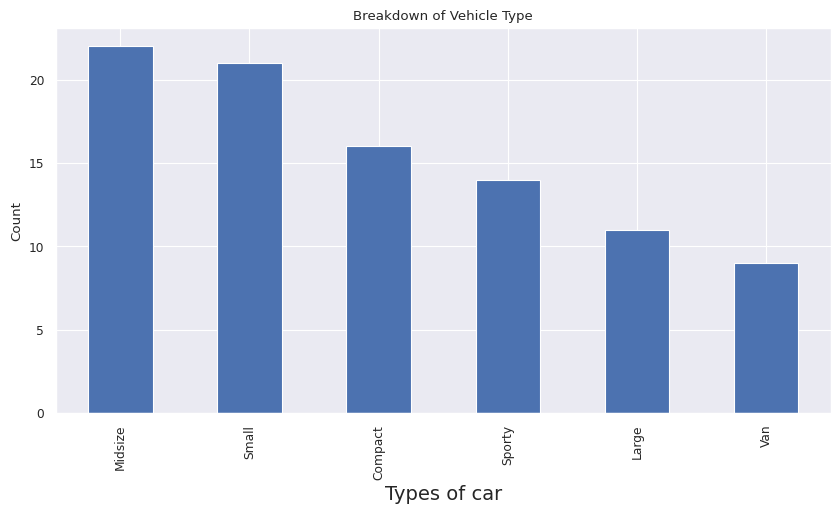

In [ ]:
#Create a new DataFrame
type_count=pd.DataFrame(cars_data['Type'].value_counts())

#types_count #uncomment to view this dataframe
type_count.plot(kind='bar', legend=False, figsize=(10,5))
plt.title("Breakdown of Vehicle Type")
plt.xlabel('Types of car', fontsize=14) #x axis label: many args to specify font type, etc...
plt.ylabel('Count')
plt.show()

The price-versus-type box-plots are valid only if each group has enough cars. Here, with roughly ten or more per type, the summaries are trustworthy; if Vans numbered only two or three, any “typical” van price would rest on too little data and shouldn’t be taken as representative.

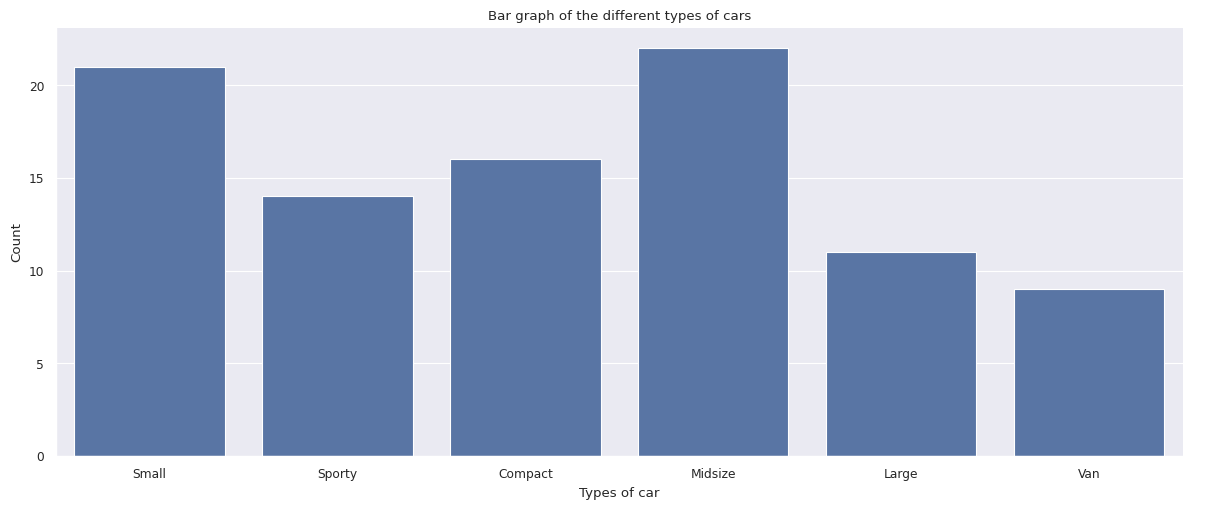

In [ ]:
#another method
car_order=["Small", 'Sporty', "Compact", "Midsize", "Large", "Van"] #define an order to plot
sns.catplot(x='Type', data=cars_data,kind='count', order=car_order,height=5, aspect=12/5)
#find those palette that maps saturation to intensity levels
#you can configure the figure size within the plotting syntax too
plt.title('Bar graph of the different types of cars')
plt.xlabel('Types of car')
plt.ylabel ('Count')
plt.show()

Note that not all Manufacturers will manufacturer cars of Type: Small, Midsize, Van, Large, Compact, Sporty. Investigate further.

If NaN occur in the following tabulation, it means the manufacturer does not manufacturer that particular type of car.

In [ ]:
cars_data.groupby(['Manufacturer', 'Type']).size().unstack()

Type,Compact,Large,Midsize,Small,Sporty,Van
Manufacturer,,,,,,
Acura,NaN,NaN,1.0,1.0,NaN,NaN
Audi,1.0,NaN,1.0,NaN,NaN,NaN
BMW,NaN,NaN,1.0,NaN,NaN,NaN
Buick,NaN,2.0,2.0,NaN,NaN,NaN
Cadillac,NaN,1.0,1.0,NaN,NaN,NaN
Chevrolet,2.0,1.0,1.0,NaN,2.0,2.0
Chrylser,NaN,1.0,NaN,NaN,NaN,NaN
Chrysler,1.0,1.0,NaN,NaN,NaN,NaN
Dodge,1.0,NaN,1.0,2.0,1.0,1.0


### Plot 4: Bar graph for Bivariate Analysis

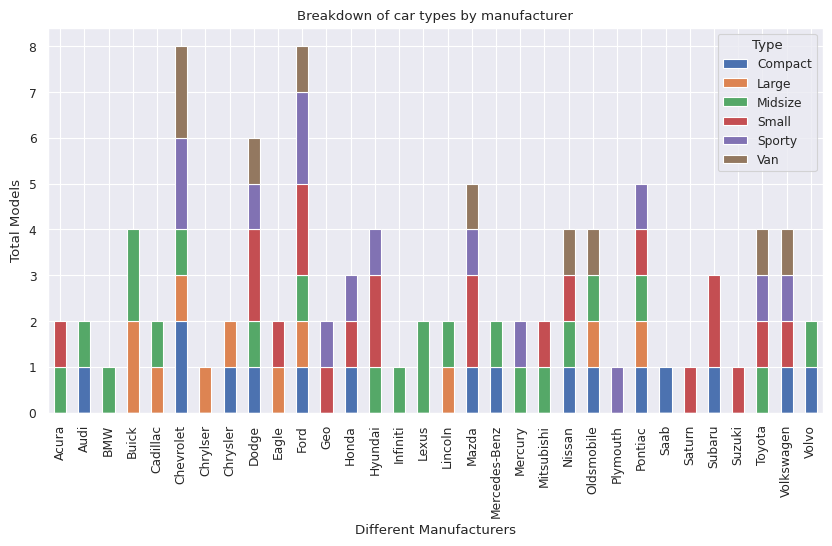

In [ ]:
#Matplotlib way
cars_data.groupby(['Manufacturer', 'Type']).size().unstack().\
    plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Breakdown of car types by manufacturer')
plt.xlabel('Different Manufacturers')
plt.ylabel('Total Models')
plt.xticks(rotation=90)
plt.show()

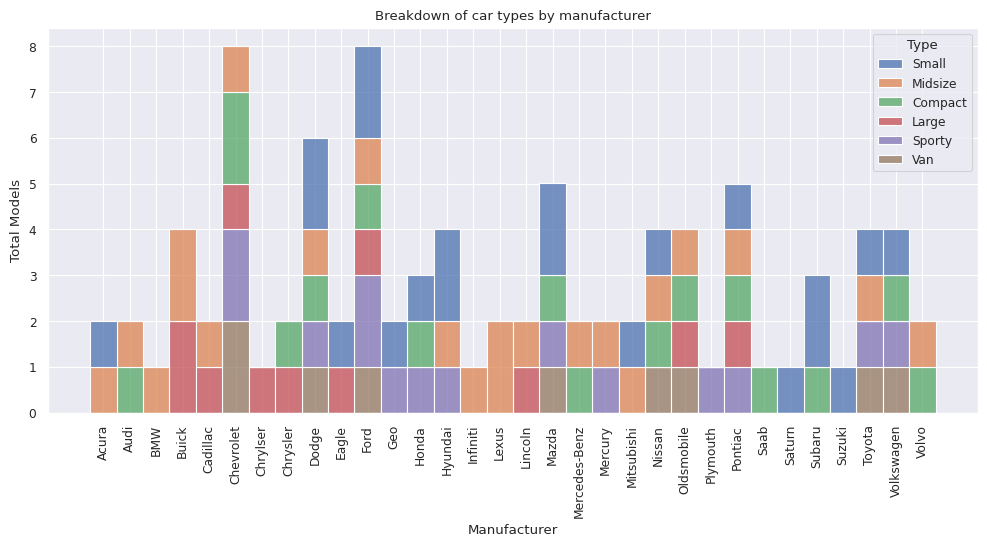

In [ ]:
#Sns way
plt.figure(figsize=(12, 5))
g=sns.histplot( x='Manufacturer', multiple='stack', hue="Type", data=cars_data)
g.set(xlabel='Manufacturer', ylabel='Total Models', \
      title='Breakdown of car types by manufacturer')
plt.xticks(rotation=90)
plt.show()

**Takeaway from the Graph**
From this graph, you can see how different car manufacturers produce a variety of car types (such as Small, Midsize, Compact, Large, Sporty, and Van). For example, Chevrolet and Ford offer the widest range of car types and have the highest number of models, while brands like Lexus or Infiniti have fewer models and less variety in types. This helps you quickly compare which manufacturers focus on specific car types and which offer a more diverse line-up.

**Why This is Bivariate Analysis**
This graph is a bivariate analysis because it shows the relationship between two categorical variables:

Manufacturer (x-axis) — the brand of the car

Type (represented by color/hue) - type within each manufacturer

Bivariate means you are looking at how two variables interact or relate to each other, not just looking at the distribution of a single variable. Here, you’re not just seeing how many car types exist (univariate), but how the types are spread across different manufacturers. This lets you spot patterns, such as which manufacturers specialise in certain car types or which ones have more diverse offerings.

### Plot 5: Multivariate Analysis

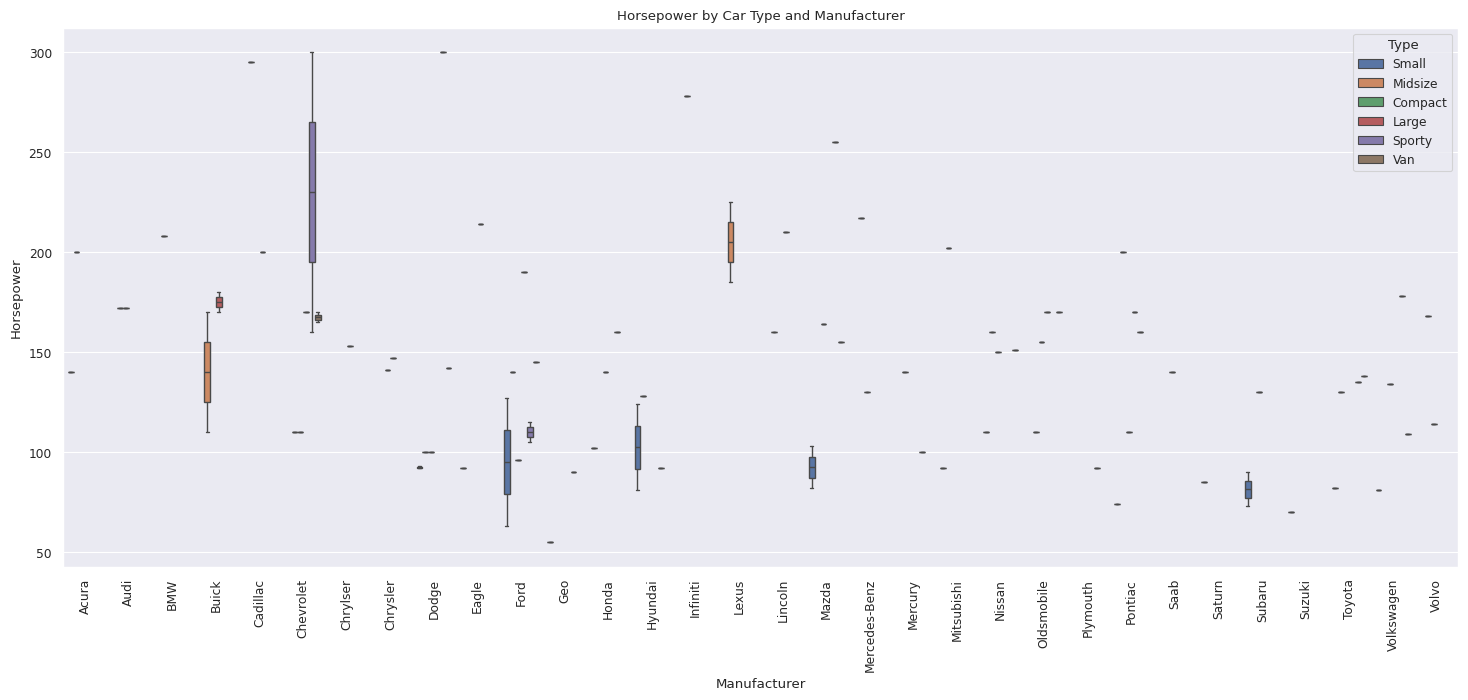

In [ ]:
plt.figure(figsize=(18, 7))
sns.boxplot(
    x='Manufacturer',
    y='Horsepower',
    hue='Type',
    data=cars_data
)
plt.title('Horsepower by Car Type and Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Horsepower')
plt.xticks(rotation=90)
plt.show()

Was there so many Chervolet cars? this does not tally with earlier bar graph. Lets dig further. Lets zoom into top 6 cars and check with stripplot

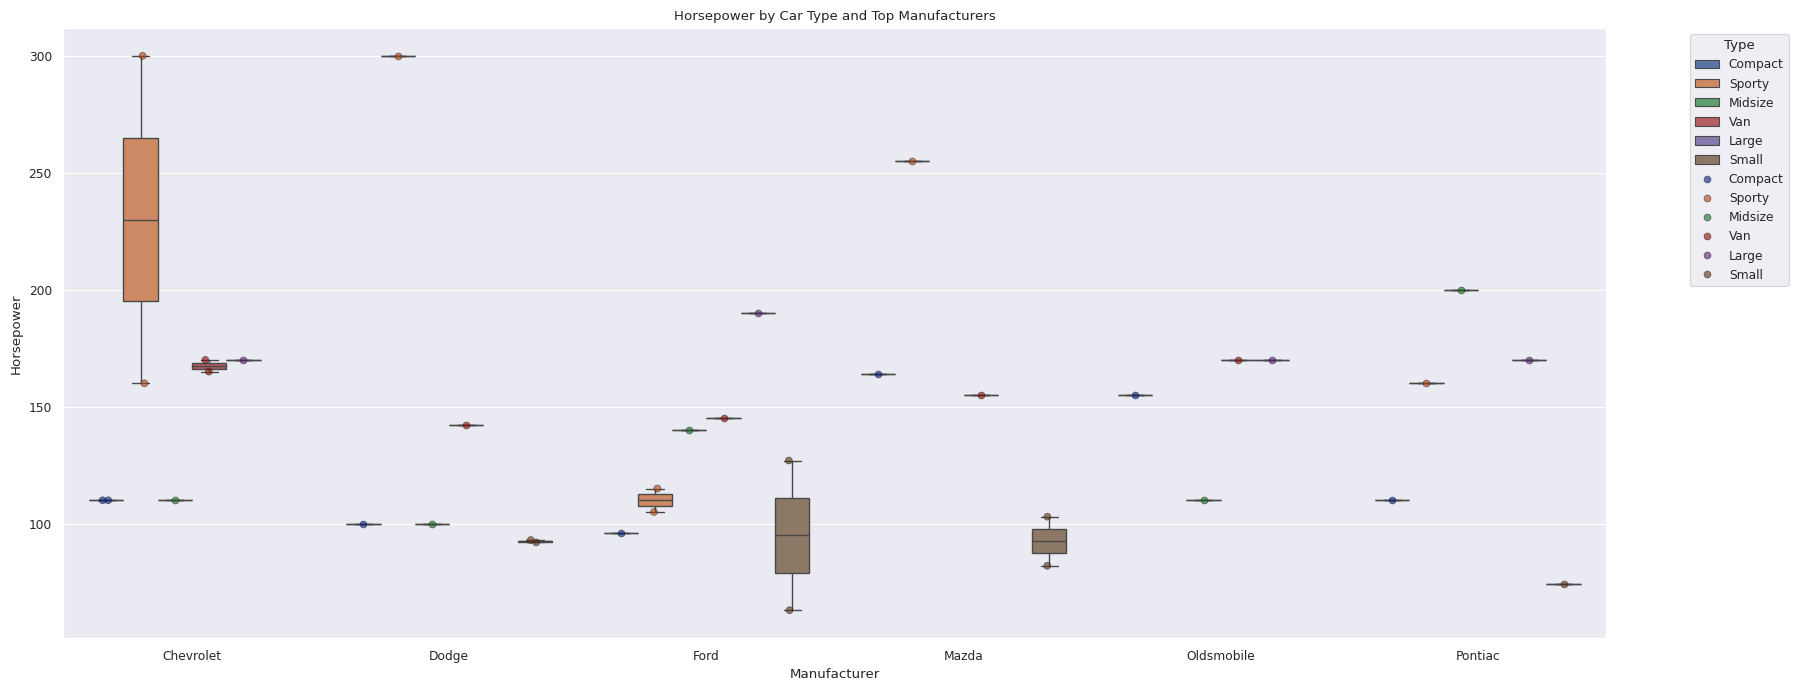

In [ ]:
# Get top 6 brands by count
top_brands = cars_data['Manufacturer'].value_counts().head(6).index.tolist()
filtered_data = cars_data[cars_data['Manufacturer'].isin(top_brands)]

plt.figure(figsize=(18, 7))

# Draw boxplot first (shows summary)
sns.boxplot(
    x='Manufacturer',
    y='Horsepower',
    hue='Type',
    data=filtered_data,
    dodge=True
)

# Overlay stripplot (shows all data points)
sns.stripplot(
    x='Manufacturer',
    y='Horsepower',
    hue='Type',
    data=filtered_data,
    dodge=True,           # Align with boxplot grouping
    jitter=True,          # Spread points for visibility
    marker='o',
    linewidth=0.5,
    alpha=0.6,            # Make dots slightly transparent
    palette='dark'        # Use same color family
)

plt.title('Horsepower by Car Type and Top Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Horsepower')
plt.xticks(rotation=0)
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()


The boxplot was misleading. It was only formed by 2 data points, similar observation for other manufacturers.

**Takeaway:** Recall your learning from DAVA. For example, boxplot without accounting for count/spread is dangerous as it can be misleading to audience.

### Plot 6: Multi with scatterplot

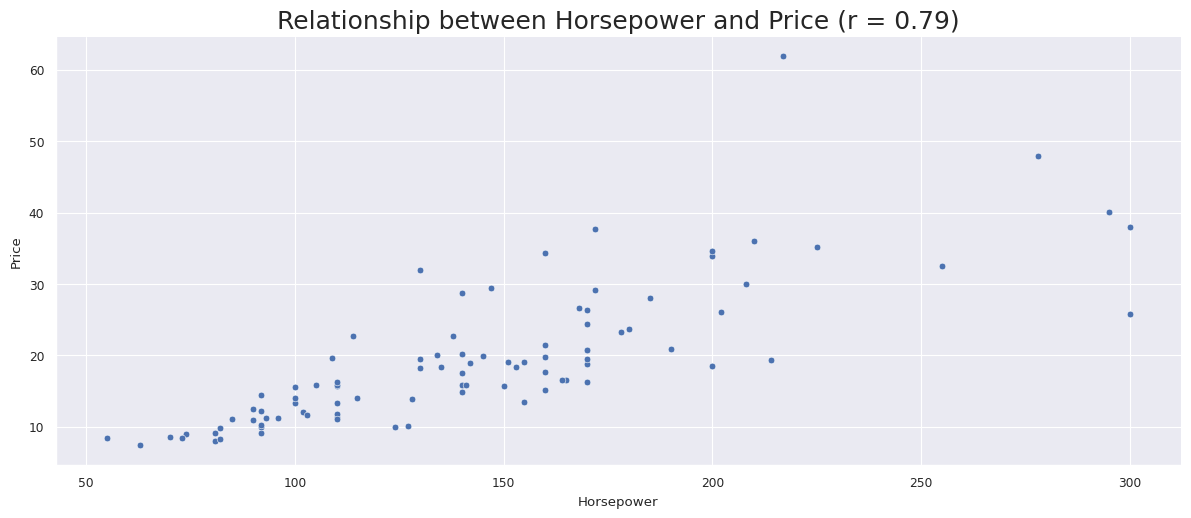

In [20]:
from scipy.stats import pearsonr

# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(cars_data['Horsepower'], cars_data['Price'])

# Plot the scatterplot
sns.relplot(x='Horsepower', y='Price', data=cars_data, kind='scatter', aspect=12/5)

# Title with r-value (rounded to 2 decimal places)
plt.title(f'Relationship between Horsepower and Price (r = {r_value:.2f})', fontsize=18)

plt.show()


**What You See in the Graphs:** <br>
Horsepower vs Price (r = 0.79): Higher horsepower usually means higher price.

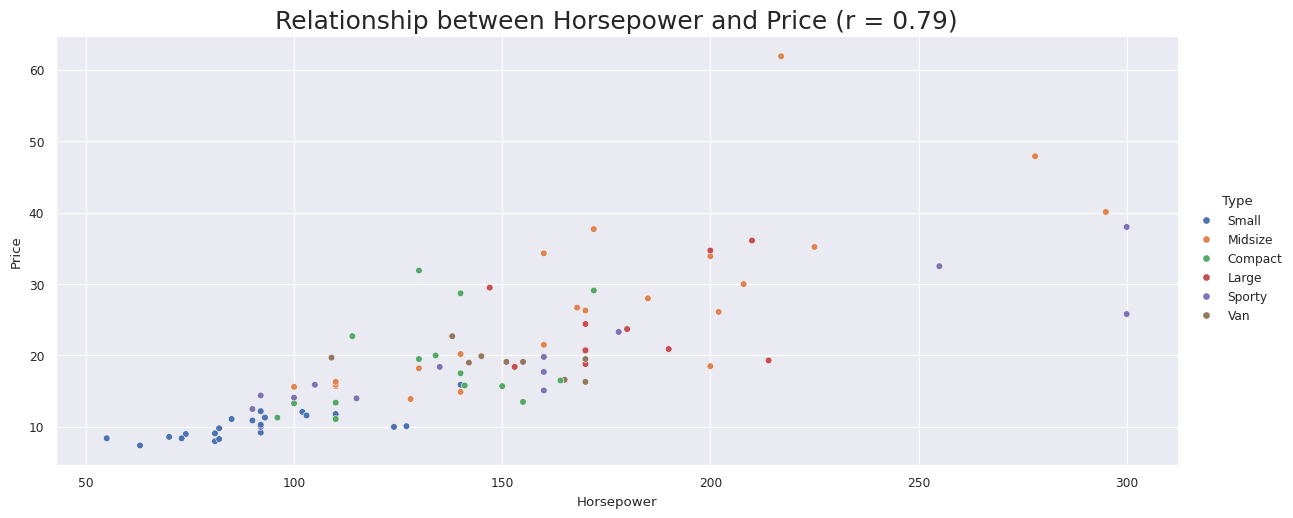

In [21]:
from scipy.stats import pearsonr

# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(cars_data['Horsepower'], cars_data['Price'])

# Plot the scatterplot
sns.relplot(x='Horsepower', y='Price', hue='Type', data=cars_data, kind='scatter', aspect=12/5)

# Title with r-value (rounded to 2 decimal places)
plt.title(f'Relationship between Horsepower and Price (r = {r_value:.2f})', fontsize=18)

plt.show()


**Takeaway:**

At first glance, the chart suggests that cars with higher horsepower are generally more expensive. However, when you include car type (shown by different colours), the relationship becomes less straightforward. For example, some sporty cars have similar horsepower but are priced very differently. This shows that factors beyond just horsepower—such as brand, features, or how a car is marketed—can also influence price, even within the same type. So, horsepower alone does not fully explain the differences in car prices.

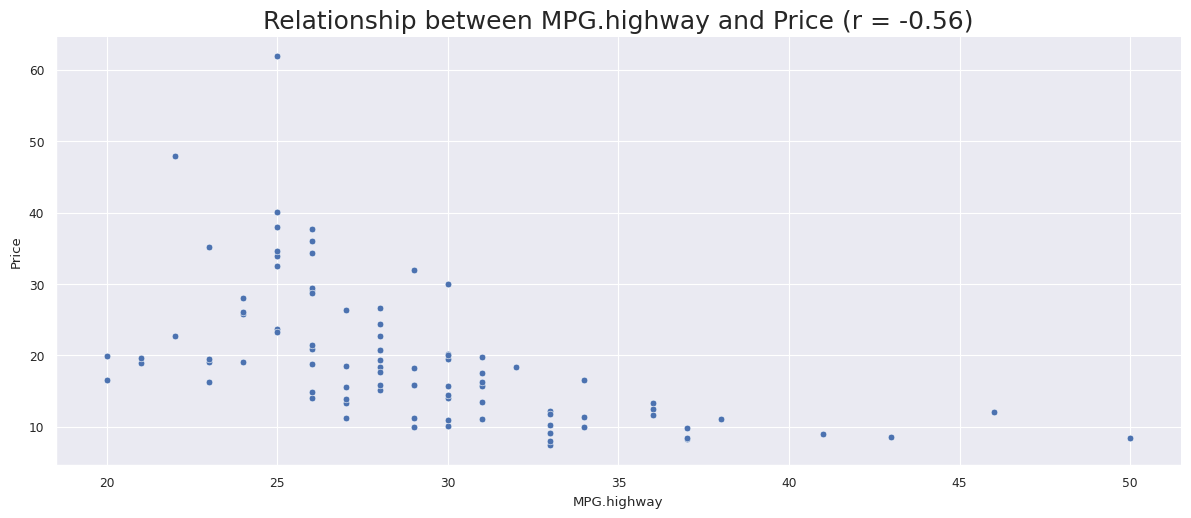

In [27]:
# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(cars_data['MPG.highway'], cars_data['Price'])

# Plot the scatterplot
sns.relplot(x='MPG.highway', y='Price',data=cars_data, kind='scatter', aspect=12/5)

# Title with r-value (rounded to 2 decimal places)
plt.title(f'Relationship between MPG.highway and Price (r = {r_value:.2f})', fontsize=18)

plt.show()


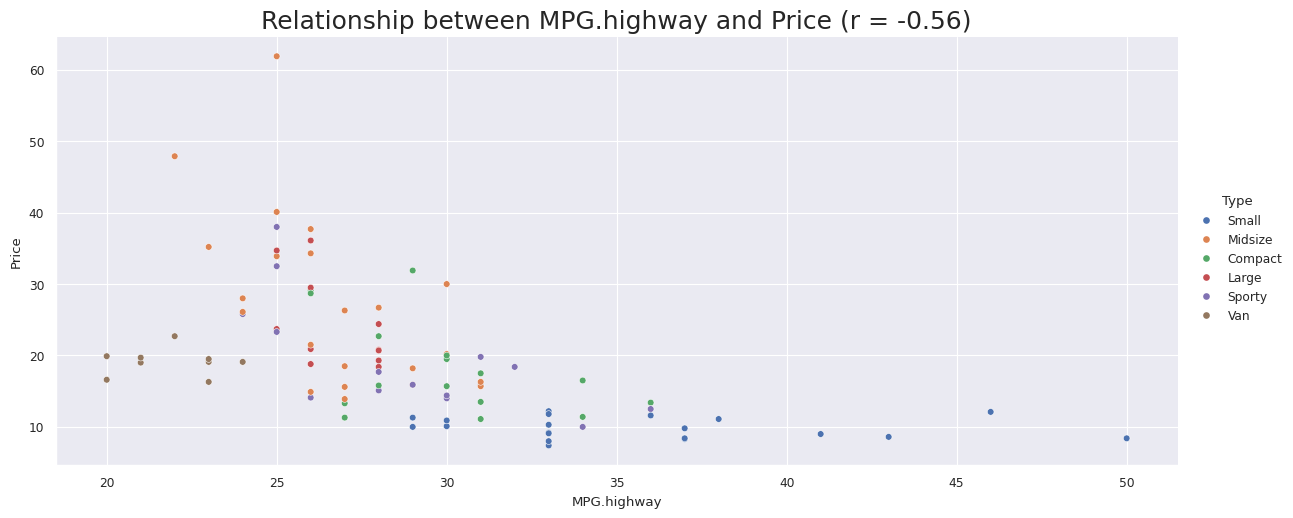

In [24]:
# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(cars_data['MPG.highway'], cars_data['Price'])

# Plot the scatterplot
sns.relplot(x='MPG.highway', y='Price', hue="Type",data=cars_data, kind='scatter', aspect=12/5)

# Title with r-value (rounded to 2 decimal places)
plt.title(f'Relationship between MPG.highway and Price (r = {r_value:.2f})', fontsize=18)

plt.show()


**Takeaway:**
The same can be said for MPG.highway VS Price. Noteably Van have low MPG.highway. The spread of Type is very different too.

**What's next? Proposed New Feature!** <br>
**Create a new variable:** <br>
Power_to_Efficiency = Horsepower_per_MPG = Horsepower / MPG.highway

**Why is this useful?**

This new variable tells you how much horsepower you get per unit of fuel efficiency.

It highlights cars that are "power-hungry" (high horsepower but low efficiency) versus those that are more balanced.

This feature may capture the trade-off between performance and efficiency, which often influences car pricing.

**How to Interpret:**

High Horsepower_per_MPG: Likely performance-focused, less efficient cars (often more expensive).

Low Horsepower_per_MPG: More efficient cars, possibly less powerful, may be cheaper.

**Why this is better?**

Compared to just looking at Horsepower or MPG alone, price can be better described with about how they balance out Power and Efficiency.

Two cars with the same horsepower can have different prices if one is much more fuel efficient.

This engineered feature combines the two aspects into a single value for easier analysis.

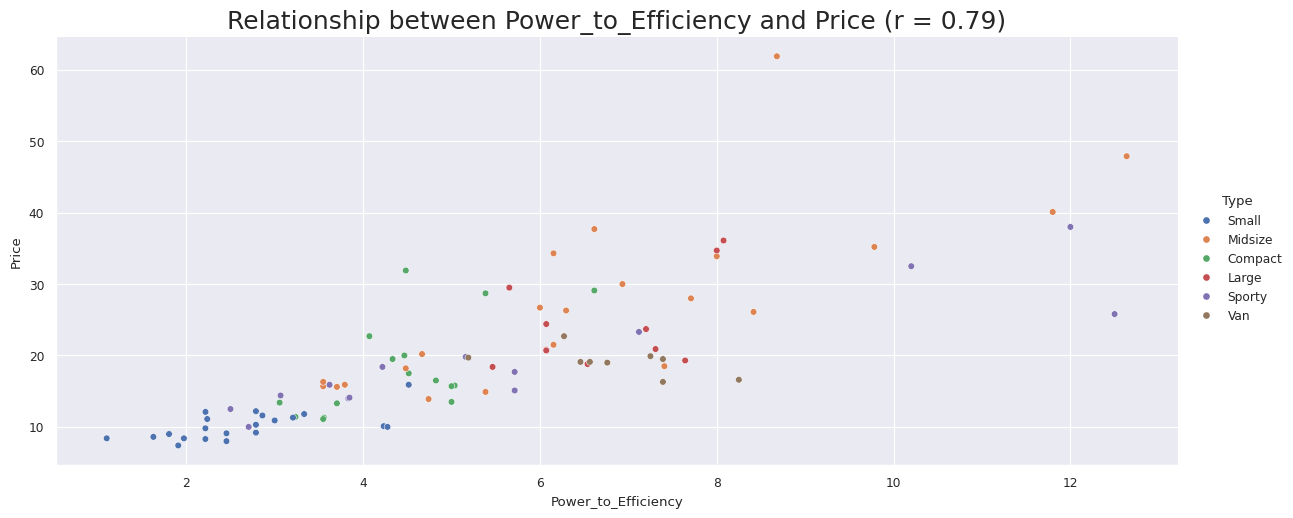

In [28]:
# Create a new column for the ratio of horsepower to highway fuel efficiency
cars_data['Power_to_Efficiency'] = cars_data['Horsepower'] / (cars_data['MPG.highway'])

# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(cars_data['Power_to_Efficiency'], cars_data['Price'])

# Plot the scatterplot
sns.relplot(x='Power_to_Efficiency', y='Price', hue='Type',data=cars_data, kind='scatter', aspect=12/5)

# Title with r-value (rounded to 2 decimal places)
plt.title(f'Relationship between Power_to_Efficiency and Price (r = {r_value:.2f})', fontsize=18)

plt.show()


### **Conclusion**

Although the correlation value (r = 0.79) for **Power\_to\_Efficiency** is the same as using horsepower alone, this new feature gives more meaningful context—especially when you also consider car type. By combining power and fuel efficiency, you can see how some cars with similar power-to-efficiency ratios can have very different prices depending on their type. This highlights that car price is influenced by a mix of performance, efficiency, and type, not just a single factor. Using engineered features helps you uncover more subtle patterns that might be hidden if you look at only one variable at a time.

---

**Key learning:**
Even when two features have the same overall correlation with price, engineered features like power-to-efficiency can provide clearer insights when combined with other information (such as car type), making your analysis more complete and realistic.


<font color = 'red'> Tutor to assure students, that they do not need to do feature engineering for project assignment 1. </font>